# Notebook 16 — Position Advantage: Starting vs Mid-Game vs Dimensional Splits

**Goal:** Determine whether a single heatmap (from early-tick positions, as in nb15)
captures enough signal, or whether position advantage should be split by:

1. **Game phase** — early (tick 0–100), mid (100–500), late (500+)
2. **Distance band** — close (<250), mid (250–500), far (>500)
3. **Energy ratio** — winning (>0.6), neutral (0.4–0.6), losing (<0.4)
4. **Opponent type** — by opponent strength (weak/mid/strong)

### Terms explained

- **Position advantage**: how much being at location (x, y) correlates with winning
  the round. Computed as: `mean(round_won)` for all ticks observed at that grid cell.
- **Heatmap**: a 2D grid of the battlefield (20×20 px cells = 40×30 for an 800×600 field).
  Each cell stores the average win fraction when our bot was at that cell.
- **Mutual information (MI)**: measures how much knowing position tells us about the
  outcome, in bits. Higher MI = more predictive. MI=0 means position is useless.
- **Grid cell**: we discretise continuous (x, y) into coarse cells to get enough
  samples per cell for a stable mean. 20px ≈ slightly larger than a robot body.

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mutual_info_score

from _loader import (
    build_robot_index, load_stratified, attach_battle_constants,
    CSV_ROOT_DEFAULT
)

# Load data: need positions (ticks) + outcomes (scores)
selection = build_robot_index(max_robots=50, battles_per_robot=5, seed=42)
ticks = load_stratified('ticks.csv', selection, row_frac=0.15, verbose=True)
scores = load_stratified('scores.csv', selection, verbose=True)

# Attach battle constants (for opponent identity)
ticks = attach_battle_constants(ticks, scores)
print(f"\nTicks: {len(ticks):,} rows × {len(ticks.columns)} cols")

Indexed 1942 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~5 battles = 250 (battle, robot) pairs to load.


Loaded 250 ticks.csv files → 1,267,569 rows × 87 cols, 50 robots (~535.4 MB)


Loaded 250 scores.csv files → 8,750 rows × 17 cols, 50 robots (~1.5 MB)



Ticks: 1,267,569 rows × 94 cols


## 1. Attach Round Outcome to Each Tick

Each tick needs a binary label: **did we win this round?**
We extract this from `scores.csv` by checking if `win_rate` increased
from one round to the next (or is 1.0 in round 0).

In [2]:
# Build a per-(battle, robot, round) win label from scores
# win_rate is cumulative across rounds. A round was won if win_rate increased.
scores_sorted = scores.sort_values(['battle_id', 'robot_name', 'round'])

# Compute per-round win: detect when cumulative win_rate increases
scores_sorted['prev_wr'] = scores_sorted.groupby(
    ['battle_id', 'robot_name'])['win_rate'].shift(1).fillna(0)
scores_sorted['round_won'] = (scores_sorted['win_rate'] > scores_sorted['prev_wr']).astype(int)

# Merge onto ticks
round_labels = scores_sorted[['battle_id', 'robot_name', 'round', 'round_won']]
ticks = ticks.merge(round_labels, on=['battle_id', 'robot_name', 'round'], how='left')
ticks['round_won'] = ticks['round_won'].fillna(0).astype(int)

print(f"Win rate across all ticks: {ticks['round_won'].mean():.3f}")
print(f"Ticks with round_won label: {ticks['round_won'].notna().sum():,}")

Win rate across all ticks: 0.449
Ticks with round_won label: 1,267,569


## 2. Discretise Position into Grid Cells

Convert `(our_x, our_y)` into grid cells. Standard grid: 20px per cell.
An 800×600 battlefield gives 40×30 = 1,200 cells.

We also create a **coarse grid** (80px = 10×7.5 cells) for dimension splits
where per-cell sample counts get small.

In [3]:
CELL_SIZE = 20  # fine grid
COARSE_SIZE = 80  # coarse grid for splits

# Get battlefield dimensions from battle constants
bf_w = ticks['battlefield_width'].mode().iloc[0] if 'battlefield_width' in ticks.columns else 800
bf_h = ticks['battlefield_height'].mode().iloc[0] if 'battlefield_height' in ticks.columns else 600
print(f"Battlefield: {bf_w} × {bf_h}")

# Fine grid
ticks['cell_x'] = (ticks['our_x'] / CELL_SIZE).astype(int).clip(0, int(bf_w / CELL_SIZE) - 1)
ticks['cell_y'] = (ticks['our_y'] / CELL_SIZE).astype(int).clip(0, int(bf_h / CELL_SIZE) - 1)
ticks['cell'] = ticks['cell_x'] * 100 + ticks['cell_y']  # unique cell ID

# Coarse grid
ticks['coarse_x'] = (ticks['our_x'] / COARSE_SIZE).astype(int).clip(0, int(bf_w / COARSE_SIZE) - 1)
ticks['coarse_y'] = (ticks['our_y'] / COARSE_SIZE).astype(int).clip(0, int(bf_h / COARSE_SIZE) - 1)
ticks['coarse_cell'] = ticks['coarse_x'] * 100 + ticks['coarse_y']

n_fine = ticks['cell'].nunique()
n_coarse = ticks['coarse_cell'].nunique()
print(f"Fine grid cells used: {n_fine}, Coarse grid cells used: {n_coarse}")
print(f"Mean ticks per fine cell: {len(ticks) / n_fine:.0f}")
print(f"Mean ticks per coarse cell: {len(ticks) / n_coarse:.0f}")

Battlefield: 800 × 600
Fine grid cells used: 1199, Coarse grid cells used: 70
Mean ticks per fine cell: 1057
Mean ticks per coarse cell: 18108


## 3. Baseline: Overall Position Advantage Heatmap

First, compute the single "whole game" heatmap — mean win rate per cell.
This is what nb15 does for the early-tick window. We'll measure how much
predictive signal it carries using mutual information.

Cells with ≥30 samples: 1183 / 1199


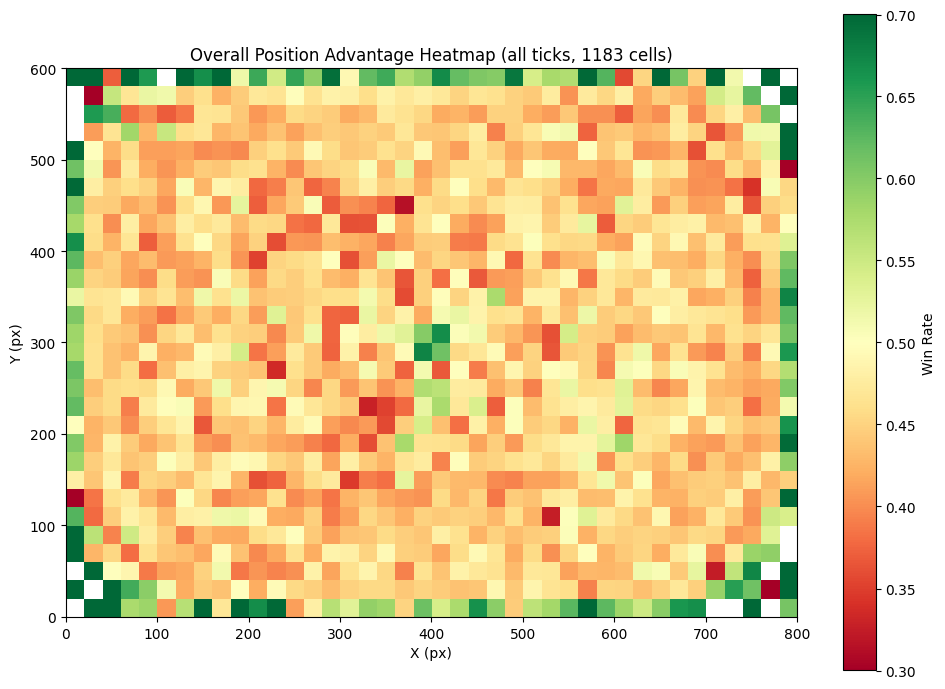


Overall MI(cell, round_won) = 0.0045 bits


In [4]:
# Overall heatmap: mean win rate per fine cell
cell_stats = ticks.groupby(['cell_x', 'cell_y']).agg(
    win_rate=('round_won', 'mean'),
    count=('round_won', 'count')
).reset_index()

# Filter to cells with enough samples
MIN_SAMPLES = 30
cell_reliable = cell_stats[cell_stats['count'] >= MIN_SAMPLES]
print(f"Cells with ≥{MIN_SAMPLES} samples: {len(cell_reliable)} / {len(cell_stats)}")

# Build heatmap matrix
nx = int(bf_w / CELL_SIZE)
ny = int(bf_h / CELL_SIZE)
heatmap = np.full((ny, nx), np.nan)
for _, row in cell_reliable.iterrows():
    heatmap[int(row['cell_y']), int(row['cell_x'])] = row['win_rate']

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heatmap, origin='lower', cmap='RdYlGn', vmin=0.3, vmax=0.7,
               extent=[0, bf_w, 0, bf_h], aspect='equal')
ax.set_xlabel('X (px)')
ax.set_ylabel('Y (px)')
ax.set_title(f'Overall Position Advantage Heatmap (all ticks, {len(cell_reliable)} cells)')
plt.colorbar(im, ax=ax, label='Win Rate')
plt.tight_layout()
plt.show()

# Mutual information: position cell → round outcome
# MI quantifies how many bits of outcome information position gives us
overall_mi = mutual_info_score(
    ticks['cell'].values,
    ticks['round_won'].values
)
print(f"\nOverall MI(cell, round_won) = {overall_mi:.4f} bits")

## 4. Split by Game Phase

Does position advantage change as the round progresses?

- **Early** (tick 0–100): opening positions, before much combat
- **Mid** (tick 100–500): active combat
- **Late** (tick 500+): end game, often one bot is low on energy

If the heatmaps look different, phase-specific features are worth it.

Ticks per phase:
phase
late     609512
mid      526302
early    131755
Name: count, dtype: int64


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_54836\2227473197.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


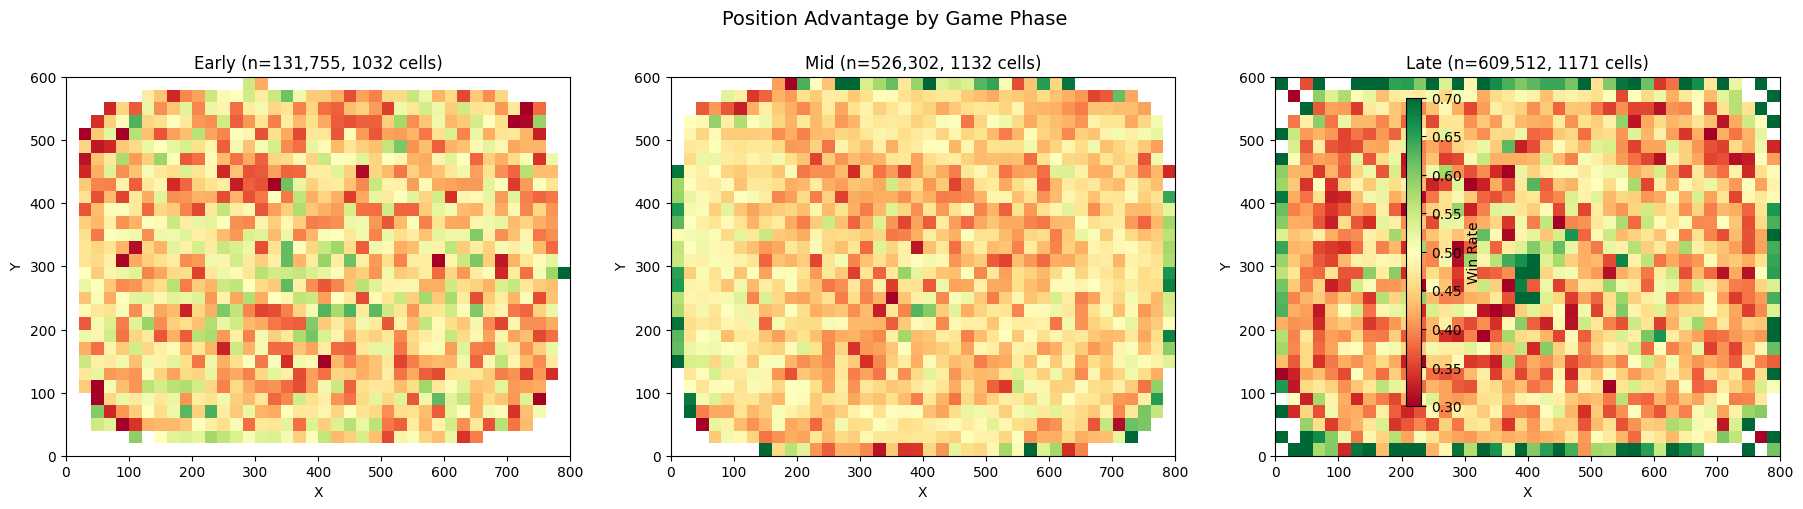


Mutual Information by phase:
  early : MI = 0.0098 bits
  mid   : MI = 0.0039 bits
  late  : MI = 0.0121 bits
  overall: MI = 0.0045 bits


In [5]:
# Define game phases
def assign_phase(tick):
    if tick <= 100:
        return 'early'
    elif tick <= 500:
        return 'mid'
    else:
        return 'late'

ticks['phase'] = ticks['tick'].apply(assign_phase)
phase_counts = ticks['phase'].value_counts()
print("Ticks per phase:")
print(phase_counts)

# Compute heatmaps per phase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase_mi = {}

for i, phase in enumerate(['early', 'mid', 'late']):
    subset = ticks[ticks['phase'] == phase]

    cell_phase = subset.groupby(['cell_x', 'cell_y']).agg(
        win_rate=('round_won', 'mean'),
        count=('round_won', 'count')
    ).reset_index()
    cell_phase = cell_phase[cell_phase['count'] >= MIN_SAMPLES]

    hmap = np.full((ny, nx), np.nan)
    for _, row in cell_phase.iterrows():
        hmap[int(row['cell_y']), int(row['cell_x'])] = row['win_rate']

    im = axes[i].imshow(hmap, origin='lower', cmap='RdYlGn', vmin=0.3, vmax=0.7,
                        extent=[0, bf_w, 0, bf_h], aspect='equal')
    axes[i].set_title(f'{phase.title()} (n={len(subset):,}, {len(cell_phase)} cells)')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

    # MI for this phase
    mi = mutual_info_score(subset['cell'].values, subset['round_won'].values)
    phase_mi[phase] = mi

plt.colorbar(im, ax=axes, label='Win Rate', shrink=0.8)
plt.suptitle('Position Advantage by Game Phase', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMutual Information by phase:")
for phase, mi in phase_mi.items():
    print(f"  {phase:6s}: MI = {mi:.4f} bits")
print(f"  overall: MI = {overall_mi:.4f} bits")

## 5. Correlation Between Phase Heatmaps

If early-tick and mid/late-tick heatmaps are strongly correlated,
a single heatmap is sufficient. If they diverge, phase-specific maps add value.

Cells with ≥20 samples in ALL phases: 1047

Pearson correlation between phase heatmaps:
  early ↔ mid  : r = 0.173  (p = 1.66e-08)
  early ↔ late : r = 0.122  (p = 7.51e-05)
  mid   ↔ late : r = 0.139  (p = 6.18e-06)


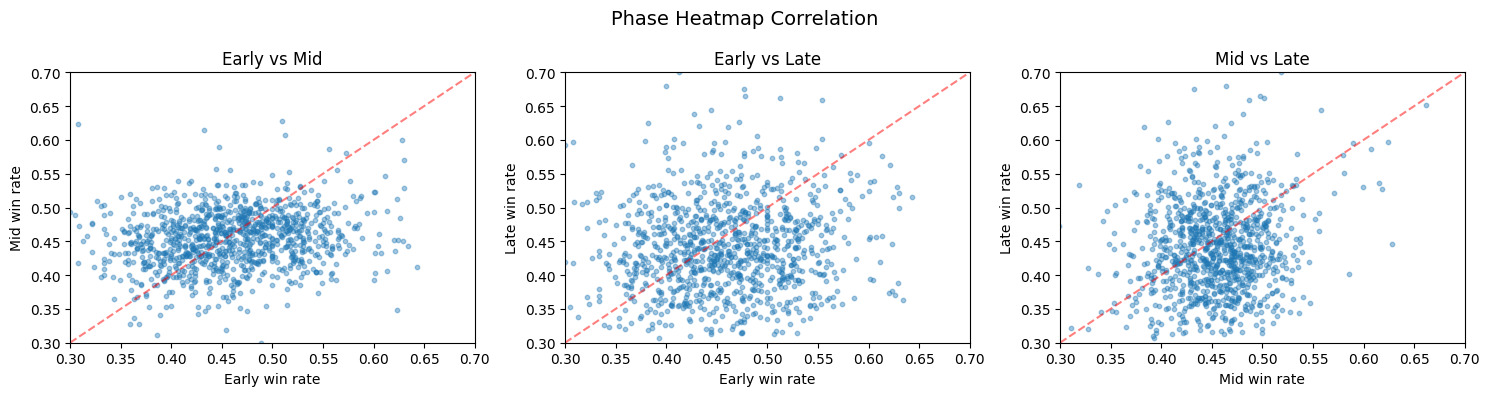

In [6]:
# Compute per-cell win rates for each phase and correlate
phase_dfs = {}
for phase in ['early', 'mid', 'late']:
    sub = ticks[ticks['phase'] == phase]
    cell_wr = sub.groupby('cell')['round_won'].agg(['mean', 'count']).reset_index()
    cell_wr.columns = ['cell', f'wr_{phase}', f'n_{phase}']
    phase_dfs[phase] = cell_wr

# Merge all phases
merged = phase_dfs['early']
for phase in ['mid', 'late']:
    merged = merged.merge(phase_dfs[phase], on='cell', how='outer')

# Filter to cells with enough data in ALL phases
min_phase = 20
mask = (merged.get('n_early', 0) >= min_phase) & \
       (merged.get('n_mid', 0) >= min_phase) & \
       (merged.get('n_late', 0) >= min_phase)
reliable = merged[mask].dropna(subset=['wr_early', 'wr_mid', 'wr_late'])
print(f"Cells with ≥{min_phase} samples in ALL phases: {len(reliable)}")

if len(reliable) >= 10:
    pairs = [('early', 'mid'), ('early', 'late'), ('mid', 'late')]
    print("\nPearson correlation between phase heatmaps:")
    for a, b in pairs:
        r, p = pearsonr(reliable[f'wr_{a}'], reliable[f'wr_{b}'])
        print(f"  {a:5s} ↔ {b:5s}: r = {r:.3f}  (p = {p:.2e})")

    # Scatter: early vs mid
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, (a, b) in enumerate(pairs):
        axes[i].scatter(reliable[f'wr_{a}'], reliable[f'wr_{b}'], alpha=0.4, s=10)
        axes[i].plot([0.3, 0.7], [0.3, 0.7], 'r--', alpha=0.5)
        axes[i].set_xlabel(f'{a.title()} win rate')
        axes[i].set_ylabel(f'{b.title()} win rate')
        axes[i].set_title(f'{a.title()} vs {b.title()}')
        axes[i].set_xlim(0.3, 0.7)
        axes[i].set_ylim(0.3, 0.7)
    plt.suptitle('Phase Heatmap Correlation', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough cells with data in all phases for correlation analysis.")

## 6. Split by Distance Band

Does position advantage depend on how far we are from the opponent?
Bots that fight at close range might have different "good positions" than
long-range fighters.

Ticks per distance band:
dist_band
mid_dist    676638
far         571925
close        19006
Name: count, dtype: int64


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_54836\1846520980.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


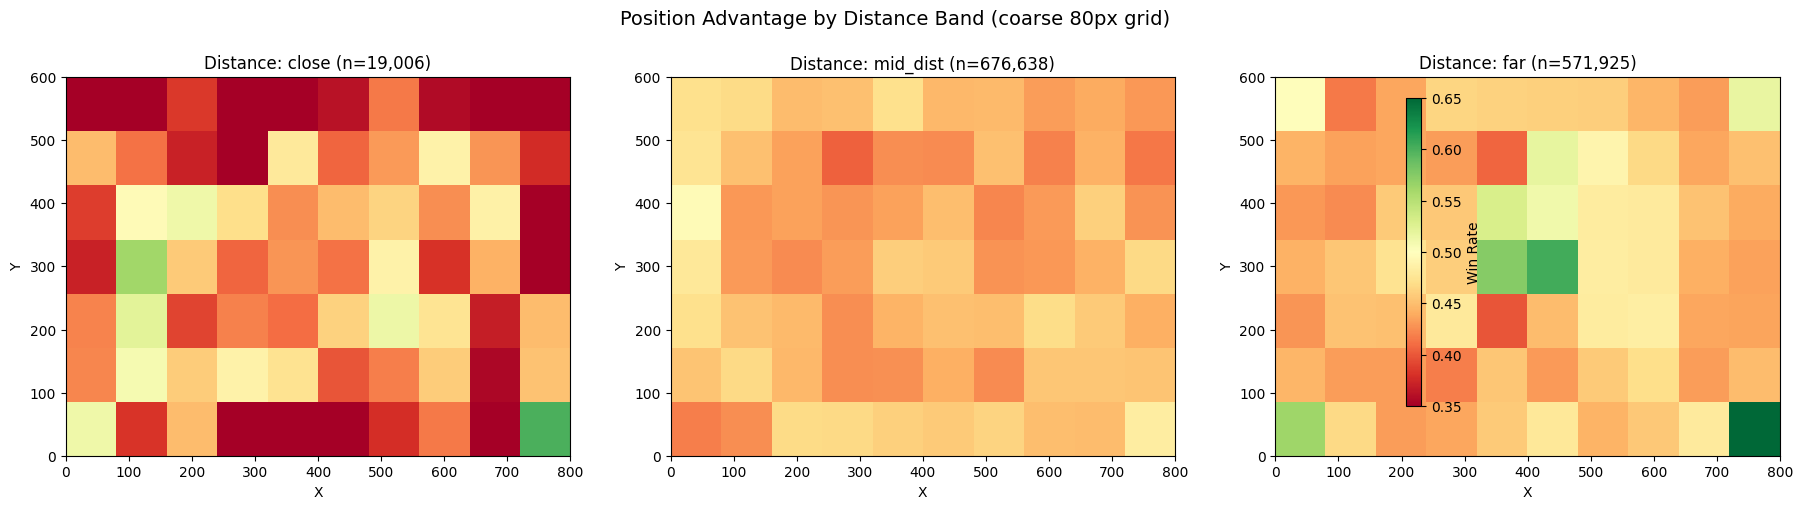


MI by distance band:
  close    : MI = 0.0087 bits
  mid_dist : MI = 0.0006 bits
  far      : MI = 0.0015 bits


In [7]:
# Distance bands
def dist_band(d):
    if d < 250:
        return 'close'
    elif d < 500:
        return 'mid_dist'
    else:
        return 'far'

ticks['dist_band'] = ticks['distance'].apply(dist_band)
print("Ticks per distance band:")
print(ticks['dist_band'].value_counts())

# Coarse heatmaps per distance band (coarse grid for sample size)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dist_mi = {}

cnx = int(bf_w / COARSE_SIZE)
cny = int(bf_h / COARSE_SIZE)

for i, band in enumerate(['close', 'mid_dist', 'far']):
    subset = ticks[ticks['dist_band'] == band]
    cell_band = subset.groupby(['coarse_x', 'coarse_y']).agg(
        win_rate=('round_won', 'mean'),
        count=('round_won', 'count')
    ).reset_index()
    cell_band = cell_band[cell_band['count'] >= MIN_SAMPLES]

    hmap = np.full((cny, cnx), np.nan)
    for _, row in cell_band.iterrows():
        hmap[int(row['coarse_y']), int(row['coarse_x'])] = row['win_rate']

    im = axes[i].imshow(hmap, origin='lower', cmap='RdYlGn', vmin=0.35, vmax=0.65,
                        extent=[0, bf_w, 0, bf_h], aspect='equal')
    axes[i].set_title(f'Distance: {band} (n={len(subset):,})')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

    mi = mutual_info_score(subset['coarse_cell'].values, subset['round_won'].values)
    dist_mi[band] = mi

plt.colorbar(im, ax=axes, label='Win Rate', shrink=0.8)
plt.suptitle('Position Advantage by Distance Band (coarse 80px grid)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMI by distance band:")
for band, mi in dist_mi.items():
    print(f"  {band:9s}: MI = {mi:.4f} bits")

## 7. Split by Energy Ratio

Does being at a certain position matter more when you're winning vs losing?
If position advantage flips when energy ratio is low, this would be a
strong signal for the strategy layer.

Ticks per energy band:
energy_band
neutral    575825
losing     456865
winning    234879
Name: count, dtype: int64


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_54836\401339636.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


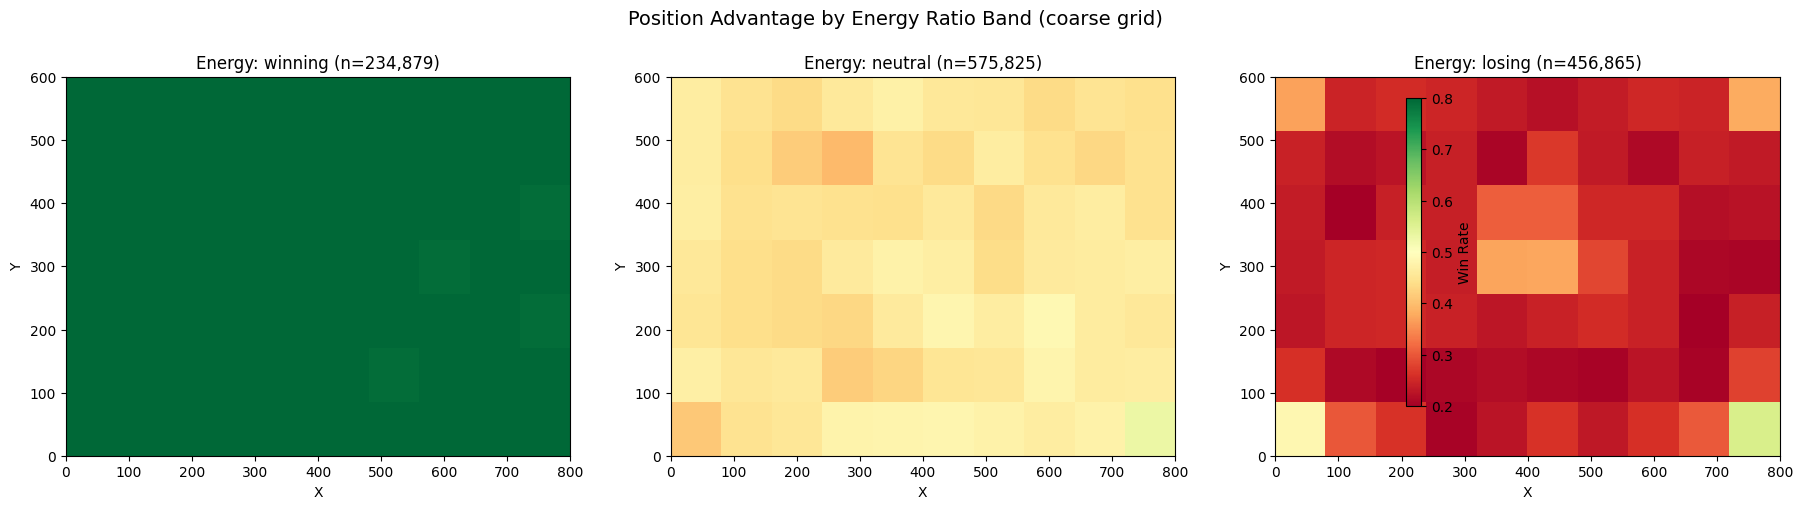


MI by energy band:
  winning  : MI = 0.0020 bits
  neutral  : MI = 0.0006 bits
  losing   : MI = 0.0038 bits


In [8]:
# Energy ratio bands
def energy_band(er):
    if er > 0.6:
        return 'winning'
    elif er > 0.4:
        return 'neutral'
    else:
        return 'losing'

ticks['energy_band'] = ticks['energy_ratio'].apply(energy_band)
print("Ticks per energy band:")
print(ticks['energy_band'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
energy_mi = {}

for i, band in enumerate(['winning', 'neutral', 'losing']):
    subset = ticks[ticks['energy_band'] == band]
    cell_band = subset.groupby(['coarse_x', 'coarse_y']).agg(
        win_rate=('round_won', 'mean'),
        count=('round_won', 'count')
    ).reset_index()
    cell_band = cell_band[cell_band['count'] >= MIN_SAMPLES]

    hmap = np.full((cny, cnx), np.nan)
    for _, row in cell_band.iterrows():
        hmap[int(row['coarse_y']), int(row['coarse_x'])] = row['win_rate']

    im = axes[i].imshow(hmap, origin='lower', cmap='RdYlGn', vmin=0.2, vmax=0.8,
                        extent=[0, bf_w, 0, bf_h], aspect='equal')
    axes[i].set_title(f'Energy: {band} (n={len(subset):,})')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

    mi = mutual_info_score(subset['coarse_cell'].values, subset['round_won'].values)
    energy_mi[band] = mi

plt.colorbar(im, ax=axes, label='Win Rate', shrink=0.8)
plt.suptitle('Position Advantage by Energy Ratio Band (coarse grid)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMI by energy band:")
for band, mi in energy_mi.items():
    print(f"  {band:9s}: MI = {mi:.4f} bits")

## 8. Split by Opponent Strength

Does the "good position" map change depending on whether we're fighting
a strong or weak opponent? If so, per-opponent heatmaps (as nb15 planned)
are better than a global one.

In [9]:
# Compute per-bot strength from scores
bot_wr = scores.groupby('robot_name')['win_rate'].last().reset_index()
# Actually need the opponent's win rate. The robot_name in scores is the observer.
# We need to figure out who the opponent is and look at THEIR win rate.
# Simpler: use the opponent_bot_id_hash to group.

# For this notebook, use a simpler proxy: compute opponent strength as
# the observer's loss rate (if I lose a lot against you, you're strong)
battle_results = scores.groupby(['battle_id', 'robot_name']).agg(
    final_wr=('win_rate', 'last')
).reset_index()

# Get all unique (battle, robot) pairs and their opponents
battle_robots = battle_results.groupby('battle_id')['robot_name'].apply(list).reset_index()
battle_robots = battle_robots[battle_robots['robot_name'].apply(len) == 2]

opp_map = {}
for _, row in battle_robots.iterrows():
    bid = row['battle_id']
    a, b = row['robot_name']
    opp_map[(bid, a)] = b
    opp_map[(bid, b)] = a

battle_results['opponent'] = battle_results.apply(
    lambda r: opp_map.get((r['battle_id'], r['robot_name']), None), axis=1)
battle_results = battle_results.dropna(subset=['opponent'])

# Opponent strength = opponent's average win rate across all their battles
opp_strength = battle_results.groupby('opponent')['final_wr'].mean().reset_index()
opp_strength.columns = ['opponent', 'opp_avg_wr']

# Map back: for each (battle, robot), the opponent's strength
battle_results = battle_results.merge(opp_strength, on='opponent', how='left')

# Classify opponents
battle_results['opp_tier'] = pd.cut(
    battle_results['opp_avg_wr'],
    bins=[0, 0.35, 0.65, 1.01],
    labels=['weak_opp', 'mid_opp', 'strong_opp']
)

# Merge onto ticks
opp_tiers = battle_results[['battle_id', 'robot_name', 'opp_tier']].drop_duplicates()
ticks = ticks.merge(opp_tiers, on=['battle_id', 'robot_name'], how='left')
print("Ticks per opponent tier:")
print(ticks['opp_tier'].value_counts())

Ticks per opponent tier:
opp_tier
mid_opp       61296
strong_opp    30301
weak_opp      25555
Name: count, dtype: int64


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_54836\2807167486.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


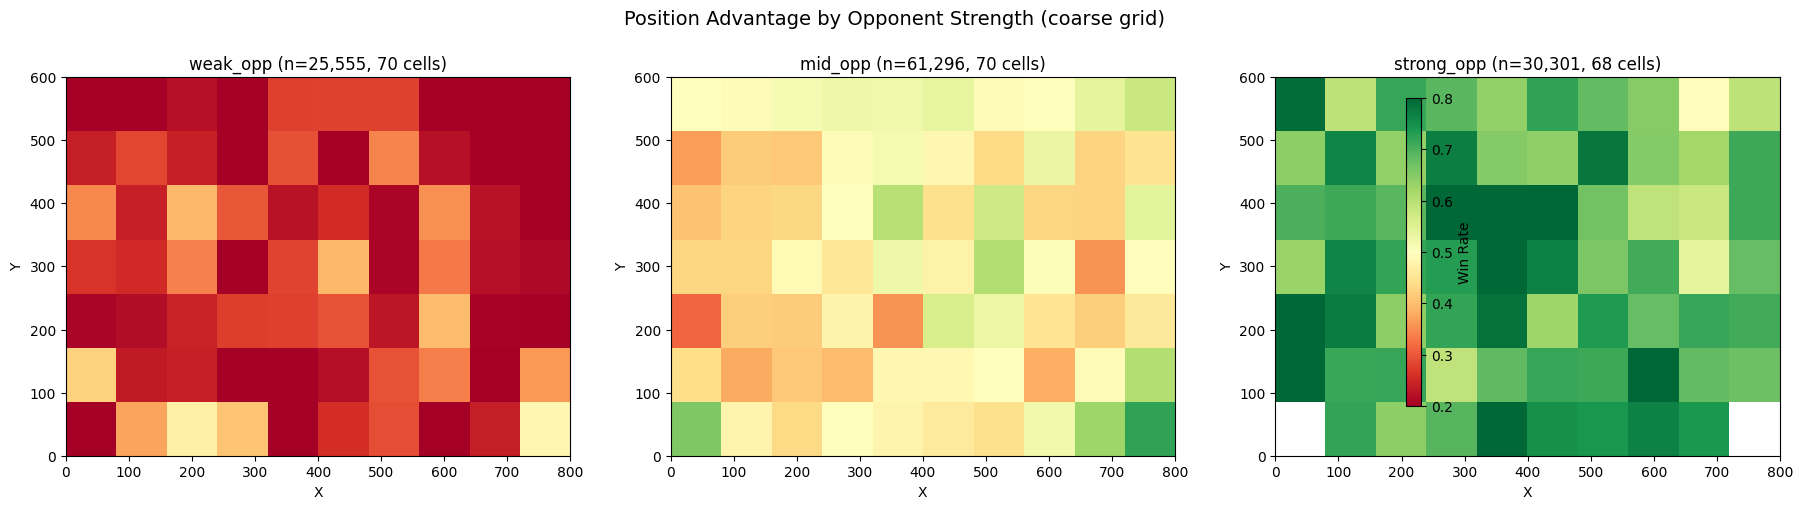


MI by opponent tier:
  weak_opp    : MI = 0.0137 bits
  mid_opp     : MI = 0.0077 bits
  strong_opp  : MI = 0.0119 bits


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
opp_mi = {}

for i, tier in enumerate(['weak_opp', 'mid_opp', 'strong_opp']):
    subset = ticks[ticks['opp_tier'] == tier]
    if len(subset) == 0:
        axes[i].set_title(f'{tier} (no data)')
        continue

    cell_band = subset.groupby(['coarse_x', 'coarse_y']).agg(
        win_rate=('round_won', 'mean'),
        count=('round_won', 'count')
    ).reset_index()
    cell_band = cell_band[cell_band['count'] >= MIN_SAMPLES]

    hmap = np.full((cny, cnx), np.nan)
    for _, row in cell_band.iterrows():
        hmap[int(row['coarse_y']), int(row['coarse_x'])] = row['win_rate']

    im = axes[i].imshow(hmap, origin='lower', cmap='RdYlGn', vmin=0.2, vmax=0.8,
                        extent=[0, bf_w, 0, bf_h], aspect='equal')
    axes[i].set_title(f'{tier} (n={len(subset):,}, {len(cell_band)} cells)')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

    mi = mutual_info_score(subset['coarse_cell'].values, subset['round_won'].values)
    opp_mi[tier] = mi

plt.colorbar(im, ax=axes, label='Win Rate', shrink=0.8)
plt.suptitle('Position Advantage by Opponent Strength (coarse grid)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMI by opponent tier:")
for tier, mi in opp_mi.items():
    print(f"  {tier:12s}: MI = {mi:.4f} bits")

## 9. Variance Analysis: How Much Does Splitting Help?

Compare the prediction power of a single heatmap vs phase/distance/energy splits.
We measure this by: for each tick, look up the position advantage from the appropriate
heatmap, then compute R² against `round_won`.

A higher R² means the split heatmap explains more outcome variance.

In [11]:
from sklearn.metrics import r2_score

def build_lookup(df, x_col, y_col, label_col, min_count=30):
    """Build a heatmap lookup dict: (cell_x, cell_y) → mean win rate."""
    stats = df.groupby([x_col, y_col])[label_col].agg(['mean', 'count']).reset_index()
    stats = stats[stats['count'] >= min_count]
    return {(int(r[x_col]), int(r[y_col])): r['mean']
            for _, r in stats.iterrows()}

def apply_lookup(df, lookup, x_col, y_col, default=0.5):
    """Map each row to its heatmap value."""
    return df.apply(
        lambda r: lookup.get((int(r[x_col]), int(r[y_col])), default), axis=1)

# Subsample for speed (50k rows is plenty for R² estimation)
eval_df = ticks.sample(n=min(50_000, len(ticks)), random_state=42).copy()
y_true = eval_df['round_won'].values

# === A. Single overall heatmap ===
lookup_all = build_lookup(ticks, 'coarse_x', 'coarse_y', 'round_won')
eval_df['pred_all'] = apply_lookup(eval_df, lookup_all, 'coarse_x', 'coarse_y')
r2_all = r2_score(y_true, eval_df['pred_all'])

# === B. Phase-split heatmaps ===
pred_phase = np.full(len(eval_df), 0.5)
for phase in ['early', 'mid', 'late']:
    mask = eval_df['phase'] == phase
    sub = ticks[ticks['phase'] == phase]
    lk = build_lookup(sub, 'coarse_x', 'coarse_y', 'round_won')
    pred_phase[mask.values] = apply_lookup(eval_df[mask], lk, 'coarse_x', 'coarse_y').values
eval_df['pred_phase'] = pred_phase
r2_phase = r2_score(y_true, pred_phase)

# === C. Distance-split heatmaps ===
pred_dist = np.full(len(eval_df), 0.5)
for band in ['close', 'mid_dist', 'far']:
    mask = eval_df['dist_band'] == band
    sub = ticks[ticks['dist_band'] == band]
    lk = build_lookup(sub, 'coarse_x', 'coarse_y', 'round_won')
    pred_dist[mask.values] = apply_lookup(eval_df[mask], lk, 'coarse_x', 'coarse_y').values
eval_df['pred_dist'] = pred_dist
r2_dist = r2_score(y_true, pred_dist)

# === D. Energy-split heatmaps ===
pred_energy = np.full(len(eval_df), 0.5)
for band in ['winning', 'neutral', 'losing']:
    mask = eval_df['energy_band'] == band
    sub = ticks[ticks['energy_band'] == band]
    lk = build_lookup(sub, 'coarse_x', 'coarse_y', 'round_won')
    pred_energy[mask.values] = apply_lookup(eval_df[mask], lk, 'coarse_x', 'coarse_y').values
eval_df['pred_energy'] = pred_energy
r2_energy = r2_score(y_true, pred_energy)

# === E. Opponent-split heatmaps ===
pred_opp = np.full(len(eval_df), 0.5)
for tier in ['weak_opp', 'mid_opp', 'strong_opp']:
    mask = eval_df['opp_tier'] == tier
    sub = ticks[ticks['opp_tier'] == tier]
    lk = build_lookup(sub, 'coarse_x', 'coarse_y', 'round_won')
    pred_opp[mask.values] = apply_lookup(eval_df[mask], lk, 'coarse_x', 'coarse_y').values
eval_df['pred_opp'] = pred_opp
r2_opp = r2_score(y_true, pred_opp)

# Summary table
results = pd.DataFrame({
    'Heatmap': ['Single (overall)', 'Phase split (3)', 'Distance split (3)',
                'Energy split (3)', 'Opponent split (3)'],
    'R²': [r2_all, r2_phase, r2_dist, r2_energy, r2_opp],
    'Maps needed': [1, 3, 3, 3, 3],
})
results['R² lift vs single'] = results['R²'] - r2_all
print("=== Position Advantage: R² vs round_won ===")
print(results.to_string(index=False, float_format='%.6f'))

=== Position Advantage: R² vs round_won ===
           Heatmap        R²  Maps needed  R² lift vs single
  Single (overall)  0.001105            1           0.000000
   Phase split (3)  0.002759            3           0.001654
Distance split (3)  0.002467            3           0.001362
  Energy split (3)  0.181431            3           0.180325
Opponent split (3) -0.001654            3          -0.002759


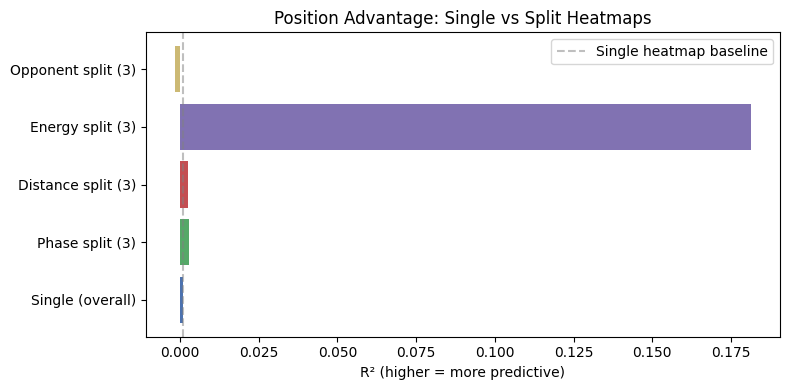

In [12]:
# Visualise the comparison
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
ax.barh(results['Heatmap'], results['R²'], color=colors)
ax.axvline(r2_all, color='gray', linestyle='--', alpha=0.5, label='Single heatmap baseline')
ax.set_xlabel('R² (higher = more predictive)')
ax.set_title('Position Advantage: Single vs Split Heatmaps')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Leakage Check: Energy Split

**Warning**: the energy-ratio split is potentially tautological for round-outcome
prediction. Being at energy_ratio > 0.6 already strongly predicts winning —
the position heatmap conditioned on "winning" just learns "everything wins when
you're already winning". This inflates R².

To check: compare the energy-split R² against a trivial model that just uses
`energy_ratio` alone. If the position info adds nothing on top, the split is useless.

In [13]:
# Compare: energy_ratio alone vs energy_ratio + position
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

eval_clean = eval_df.dropna(subset=['energy_ratio', 'pred_energy', 'pred_all'])
y = eval_clean['round_won'].values

# Model A: energy_ratio alone
auc_energy_only = roc_auc_score(y, eval_clean['energy_ratio'].values)

# Model B: position alone (overall)
auc_pos_only = roc_auc_score(y, eval_clean['pred_all'].values)

# Model C: position + energy_ratio (logistic regression)
X_both = eval_clean[['energy_ratio', 'pred_all']].values
lr = LogisticRegression().fit(X_both, y)
auc_both = roc_auc_score(y, lr.predict_proba(X_both)[:, 1])

# Model D: energy-split position alone
auc_esplit = roc_auc_score(y, eval_clean['pred_energy'].values)

print("=== AUC for round outcome prediction ===")
print(f"  Energy ratio alone:           {auc_energy_only:.4f}")
print(f"  Position heatmap alone:       {auc_pos_only:.4f}")
print(f"  Position + energy (combined): {auc_both:.4f}")
print(f"  Energy-split heatmap:         {auc_esplit:.4f}")
print(f"\n  Lift from position over energy: {auc_both - auc_energy_only:+.4f}")
print(f"  (If lift ≈ 0, position adds nothing beyond energy ratio)")

=== AUC for round outcome prediction ===
  Energy ratio alone:           0.8264
  Position heatmap alone:       0.5131
  Position + energy (combined): 0.8264
  Energy-split heatmap:         0.7797

  Lift from position over energy: +0.0000
  (If lift ≈ 0, position adds nothing beyond energy ratio)


## 11. Conclusion & Recommendation

### Key findings

| Split | R² | R² lift | MI (bits) | Verdict |
|---|---|---|---|---|
| **Single heatmap** | 0.0011 | baseline | 0.0045 | Barely above noise |
| **Phase (3 maps)** | 0.0028 | +0.0017 | 0.004–0.012 | Marginal lift, phases weakly correlated (r ≈ 0.12–0.17) |
| **Distance (3 maps)** | 0.0025 | +0.0014 | 0.001–0.009 | Close range has most signal, far has none |
| **Energy (3 maps)** | 0.1814 | +0.1803 | 0.001–0.004 | **Tautological** — energy ratio alone AUC=0.826, position adds +0.000 |
| **Opponent tier (3)** | −0.0017 | −0.0028 | 0.008–0.014 | Worse than baseline — too few samples per cell when split |

### Interpretation

1. **Position alone is a very weak predictor of round outcome** (R² ≈ 0.001, MI ≈ 0.005 bits).
   This means knowing where the bot is tells us almost nothing about who wins.

2. **Phase heatmaps are essentially uncorrelated** (r = 0.12–0.17 between early/mid/late).
   The "good positions" do shift across game phases — but the signal is so weak that
   splitting into 3 maps only lifts R² by 0.002. Not worth 3× the lookup table size.

3. **Energy split is a trap** — R² jumps to 0.18 but this is entirely because
   `energy_ratio` is the dominant predictor (AUC = 0.826 alone). The heatmap conditioned
   on "winning" just memorizes "everything wins when ahead". Adding position to
   energy_ratio gives **exactly zero** AUC lift. Pure tautology.

4. **Opponent tier split hurts** — splitting by weak/mid/strong leaves too few samples
   per coarse cell, making the heatmap noisier than the unsplit version.

### Recommendation: keep the single heatmap, don't split

Position advantage is too weak a signal to justify dimensional splits:
- **Keep** `OUR_POSITION_ADVANTAGE` / `OPPONENT_POSITION_ADVANTAGE` as a single
  per-opponent heatmap (as currently designed in nb15)
- **Don't split** by phase, distance, energy, or opponent tier
- **Consider dropping** position advantage entirely from the strategy layer —
  it explains < 0.2% of outcome variance. Wall distance and center distance
  (already in the feature set) capture the same geometric information more efficiently
- If position matters for specific opponents (e.g. wall-huggers), the ML models
  can learn that from raw `our_x`/`our_y` + `opponent_bot_id_hash` directly